In [2]:
import sys
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import subprocess

import os

import cell2location
import scvi

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text
import seaborn as sns
from scipy.sparse import csr_matrix
from cell2location.utils.filtering import filter_genes

https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_tutorial.html

## Load reference

In [3]:
adata_ref = sc.read_h5ad("../data/immune_reference/sc.h5ad")
adata_ref

AnnData object with n_obs × n_vars = 73260 × 10237
    obs: 'Age', 'BCELL_CLONE', 'BCELL_CLONE_SIZE', 'Donor', 'ID', 'IGH_MU_FREQ', 'ISOTYPE', 'LibraryID', 'Method', 'Population', 'PrelimCellType', 'Sample', 'Sex', 'Study', 'Tissue', 'barcode', 'batch', 'doublet_score', 'index', 'predicted_doublet', 'percent_mito', 'n_counts', 'n_genes', 'S_score', 'G2M_score', 'phase', 'VDJsum', 'cell_cycle_diff', 'PrelimCellType_new', 'leiden', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'CellType', 'CellType2', 'Subset', 'Subset_Broad', 'Subset_all', 'new_celltype', 'Subset_int', 'Subset_print'
    var: 'GeneID-2', 'GeneName-2', 'feature_types', 'feature_types-0', 'feature_types-1', 'gene_ids-1', 'gene_ids-4861STDY7135913-0', 'gene_ids-4861STDY7135914-0', 'gene_ids-4861STDY7208412-0', 'gene_ids-4861STDY7208413-0', 'gene_ids-Human_colon_16S7255677-0', 'gene_ids-Human_colon_16S7255678-0', 'gene_ids-Human_colon_16S8000484-0', 'gene_ids-Pan_T7935494-0', 'genome-1', 'n_cells', 'nonz_mean', 'mean_cov_

In [4]:
adata_ref.var.head()

,GeneID-2,GeneName-2,feature_types,feature_types-0,feature_types-1,gene_ids-1,gene_ids-4861STDY7135913-0,gene_ids-4861STDY7135914-0,gene_ids-4861STDY7208412-0,gene_ids-4861STDY7208413-0,...,mean_sample_effectSample_BCP003_Total,mean_sample_effectSample_BCP004_Total,mean_sample_effectSample_BCP005_Total,mean_sample_effectSample_BCP006_Total,mean_sample_effectSample_BCP008_Total,mean_sample_effectSample_BCP009_Total,mean_sample_effectSample_Human_colon_16S7255677,mean_sample_effectSample_Human_colon_16S7255678,mean_sample_effectSample_Human_colon_16S8000484,mean_sample_effectSample_Pan_T7935494
NOC2L,ENSG00000188976,16551,nan,Gene Expression,Gene Expression,ENSG00000188976,ENSG00000188976,ENSG00000188976,ENSG00000188976,ENSG00000188976,...,0.024621,0.081671,0.026212,0.036554,0.062046,0.002198,0.005277,0.051860,0.071570,0.005360
HES4,ENSG00000188290,11070,nan,Gene Expression,Gene Expression,ENSG00000188290,ENSG00000188290,ENSG00000188290,ENSG00000188290,ENSG00000188290,...,0.000226,0.000077,0.000084,0.000147,0.001873,0.001898,0.238216,0.416655,0.000570,0.000235
ISG15,ENSG00000187608,12375,nan,Gene Expression,Gene Expression,ENSG00000187608,ENSG00000187608,ENSG00000187608,ENSG00000187608,ENSG00000187608,...,0.076364,0.269649,0.076759,0.353826,0.302668,0.075711,0.163041,0.147128,0.000370,0.002196
TNFRSF18,ENSG00000186891,31000,nan,Gene Expression,Gene Expression,ENSG00000186891,ENSG00000186891,ENSG00000186891,ENSG00000186891,ENSG00000186891,...,0.001377,0.001578,0.019400,0.010306,0.011950,0.005170,0.001284,0.003092,0.003714,0.000049
TNFRSF4,ENSG00000186827,30985,nan,Gene Expression,Gene Expression,ENSG00000186827,ENSG00000186827,ENSG00000186827,ENSG00000186827,ENSG00000186827,...,0.001522,0.016071,0.006540,0.017655,0.007901,0.006553,0.176486,0.001475,0.036219,0.000095


In [5]:
adata_ref.var['SYMBOL'] = adata_ref.var.index
# rename 'GeneID-2' as necessary for your data
adata_ref.var.set_index('GeneID-2', drop=True, inplace=True)

## Load spatial

In [6]:
adata_vis = sc.read_visium(path="../data/human_lymph_node/", 
                           count_file="V1_Human_Lymph_Node_filtered_feature_bc_matrix.h5")

/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
adata_vis

AnnData object with n_obs × n_vars = 4035 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [8]:
list(adata_vis.uns['spatial'].keys())

['V1_Human_Lymph_Node']

In [9]:
adata_vis.obs['sample'] = list(adata_vis.uns['spatial'].keys())[0]

In [10]:
adata_vis.var.head()

,gene_ids,feature_types,genome
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38
AL627309.1,ENSG00000238009,Gene Expression,GRCh38
AL627309.3,ENSG00000239945,Gene Expression,GRCh38


In [11]:
adata_vis.var['SYMBOL'] = adata_vis.var_names
adata_vis.var.set_index('gene_ids', drop=True, inplace=True)

In [12]:
# find mitochondria-encoded (MT) genes
adata_vis.var['MT_gene'] = [gene.startswith('MT-') for gene in adata_vis.var['SYMBOL']]

# remove MT genes for spatial mapping (keeping their counts in the object)
adata_vis.obsm['MT'] = adata_vis[:, adata_vis.var['MT_gene'].values].X.toarray()
adata_vis = adata_vis[:, ~adata_vis.var['MT_gene'].values]

## Filter genes on reference

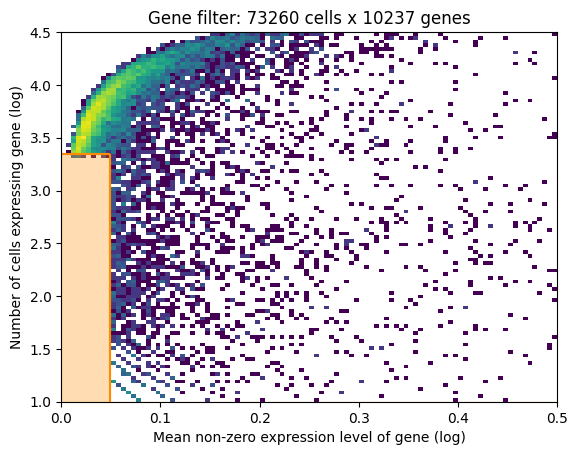

In [13]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

# filter the object
adata_ref = adata_ref[:, selected].copy()

In [14]:
adata_ref.obs.head()

,Age,BCELL_CLONE,BCELL_CLONE_SIZE,Donor,ID,IGH_MU_FREQ,ISOTYPE,LibraryID,Method,Population,...,leiden_3,leiden_4,CellType,CellType2,Subset,Subset_Broad,Subset_all,new_celltype,Subset_int,Subset_print
AAACCTGGTAGAGCTG-1-4861STDY7135913,60-64y,nan,NaN,290b,4861STDY7135913,NaN,nan,A3-mLN-0-F1-1,3GEX,CD4+ T cells,...,15,15,TfH_3,TfH_3,T_CD4+_TfH,T_CD4+_TfH,T_CD4+_TfH,T_CD4+_TfH,24,24_T_CD4+_TfH
AAACCTGGTGTCAATC-1-4861STDY7135913,60-64y,nan,NaN,290b,4861STDY7135913,NaN,nan,A3-mLN-0-F1-1,3GEX,CD4+ T cells,...,7,7,T_CD4+_1,T_CD4+_1,T_CD4+_naive,T_CD4+_naive,T_CD4+_naive,T_CD4+_naive,26,26_T_CD4+_naive
AAACCTGTCAGAGGTG-1-4861STDY7135913,60-64y,nan,NaN,290b,4861STDY7135913,NaN,nan,A3-mLN-0-F1-1,3GEX,CD4+ T cells,...,16,16,T_CD8+_2,T_CD8+_2,T_CD8+_CD161+,T_CD8+_CD161+,T_CD8+_CD161+,T_CD8+_CD161+,27,27_T_CD8+_CD161+
AAACGGGAGAGATGAG-1-4861STDY7135913,60-64y,nan,NaN,290b,4861STDY7135913,NaN,nan,A3-mLN-0-F1-1,3GEX,CD4+ T cells,...,15,15,TfH_3,TfH_3,T_CD4+_TfH,T_CD4+_TfH,T_CD4+_TfH,T_CD4+_TfH,24,24_T_CD4+_TfH
AAACGGGAGTATGACA-1-4861STDY7135913,60-64y,nan,NaN,290b,4861STDY7135913,NaN,nan,A3-mLN-0-F1-1,3GEX,CD4+ T cells,...,5,5,TfH_1,TfH_1,T_CD4+_TfH_GC,T_CD4+_TfH_GC,T_CD4+_TfH_GC,T_CD4+_TfH_GC,25,25_T_CD4+_TfH_GC


## Training on refrence

In [15]:
adata_ref.obs['Sample'].value_counts()

Sample
BCP005_Total              13323
BCP006_Total               4531
4861STDY7462253            4286
4861STDY7462255            4283
4861STDY7528597            3888
BCP009_Total               3867
4861STDY7462256            3852
4861STDY7528600            3594
4861STDY7528599            3172
4861STDY7135914            3126
4861STDY7462254            3085
4861STDY7528598            2961
4861STDY7135913            2941
BCP008_Total               2914
Pan_T7935494               2876
BCP003_Total               2083
BCP002_Total               2002
Human_colon_16S8000484     1308
4861STDY7208413            1228
4861STDY7208412            1130
Human_colon_16S7255678     1125
BCP004_Total                985
Human_colon_16S7255677      700
Name: count, dtype: int64

In [16]:
adata_ref.obs['Method'].value_counts()

Method
5GEX    45502
3GEX    27758
Name: count, dtype: int64

In [17]:
adata_ref.obs['Subset'].value_counts()

Subset
B_mem               13476
B_naive              8924
T_CD4+_naive         6012
B_Cycling            4765
T_CD4+_TfH           4690
T_CD8+_cytotoxic     3890
T_CD4+_TfH_GC        3653
B_activated          3575
B_GC_LZ              3298
T_CD4+               3059
T_Treg               2958
B_GC_DZ              2500
T_CD8+_CD161+        2294
T_CD8+_naive         2253
NK                   1372
B_plasma             1094
T_TfR                1065
NKT                   896
Endo                  622
ILC                   617
B_preGC               404
T_TIM3+               357
Monocytes             306
DC_pDC                226
B_IFN                 199
DC_cDC2               173
Macrophages_M1        121
Macrophages_M2        110
DC_cDC1               101
FDC                    76
B_GC_prePB             74
DC_CCR7+               42
VSMC                   40
Mast                   18
Name: count, dtype: int64

In [18]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref,
                        # 10X reaction / sample / batch
                        batch_key='Sample',
                        # cell type, covariate used for constructing signatures
                        labels_key='Subset',
                        # multiplicative technical effects (platform, 3' vs 5', donor effect)
                        categorical_covariate_keys=['Method']
                       )

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.



In [19]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref)

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.4.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Sample',
│   'labels_key': 'Subset',
│   'categorical_covariate_keys': ['Method'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  23   │
│         n_cells          │ 73260 │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  34   │
│          n_vars          │ 10237 │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                         batch State Registry                         
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃       Categories       ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Sample'] │    4861STDY7135913     │          0          │
│                     │    4861STDY7135914     │          1          │
│                     │    4861STDY7208412     │          2          │
│                     │    4861STDY7208413     │          3          │
│                     │    4861STDY7462253     │          4          │
│                     │    4861STDY7462254     │          5          │
│                     │    4861STDY7462255     │          6          │
│                     │    4861STDY7462256     │          7          │
│                     │    4861STDY7528597     │          8          │
│                     │    4861STDY7528598     │          9          │
│                     │    4861STDY7528599     │         10          │
│                     │    4861STDY7528600     │         11          │
│                     │      BCP002_Total      │         12          │
│                     │      BCP003_Total      │         13          │
│                     │      BCP004_Total      │         14          │
│                     │      BCP005_Total      │         15          │
│                     │      BCP006_Total      │         16          │
│                     │      BCP008_Total      │         17          │
│                     │      BCP009_Total      │         18          │
│                     │ Human_colon_16S7255677 │         19          │
│                     │ Human_colon_16S7255678 │         20          │
│                     │ Human_colon_16S8000484 │         21          │
│                     │      Pan_T7935494      │         22          │
└─────────────────────┴────────────────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃    Categories    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Subset'] │    B_Cycling     │          0          │
│                     │     B_GC_DZ      │          1          │
│                     │     B_GC_LZ      │          2          │
│                     │    B_GC_prePB    │          3          │
│                     │      B_IFN       │          4          │
│                     │   B_activated    │          5          │
│                     │      B_mem       │          6          │
│                     │     B_naive      │          7          │
│                     │     B_plasma     │          8          │
│                     │     B_preGC      │          9          │
│                     │     DC_CCR7+     │         10          │
│                     │     DC_cDC1      │         11          │
│                     │     DC_cDC2      │         12          │
│                     │      DC_pDC      │         13          │
│                     │       Endo       │         14          │
│                     │       FDC        │         15          │
│                     │       ILC        │         16          │
│                     │  Macrophages_M1  │         17          │
│                     │  Macrophages_M2  │         18          │
│                     │       Mast       │         19          │
│                     │    Monocytes     │         20          │
│                     │        NK        │         21          │
│                     │       NKT        │         22          │
│                     │      T_CD4+      │         23          │
│                     │    T_CD4+_TfH    │         24          │
│                     │  T_CD4+_TfH_GC   │         25          │
│                     │   T_CD4+_naive   │         26          │
│                     │  T_CD8+_CD161+   │         27          │
│                     │ T_CD8+_cytotoxic │         28          │
│                     │   T_CD8+_naive   │         29          │
│                     │     T_TIM3+      │         30          │
│                     │      T_TfR       │         31          │
│                     │      T_Treg      │         32          │
│                     │       VSMC       │         33          │
└─────────────────────┴──────────────────┴─────────────────────┘

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Method'] │    3GEX    │          0          │
│                     │    5GEX    │          1          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

In [ ]:
import torch
if torch.cuda.is_available():
    mod.train(max_epochs=150, batch_size=5000, use_gpu=True)
else:
    mod.train(max_epochs=150, batch_size=5000, use_gpu=False)

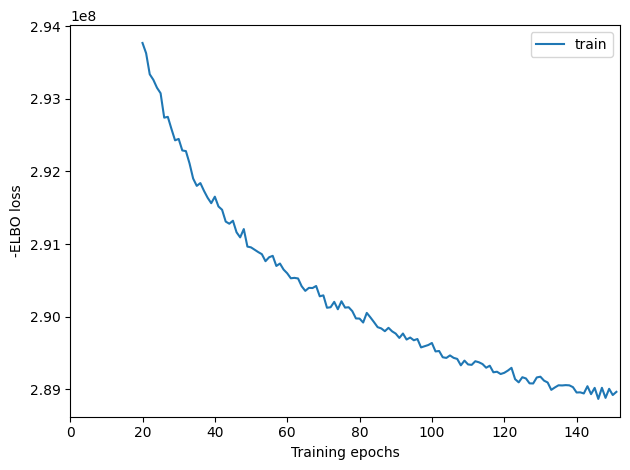

In [27]:
mod.plot_history(20)

In [29]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
import torch
if torch.cuda.is_available():
    adata_ref = mod.export_posterior(adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 5000, 'use_gpu': True})
else:
    adata_ref = mod.export_posterior(adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 5000, 'use_gpu': False})

/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling global variables, sample: 100%|█████████████| 999/999 [00:11<00:00, 87.30it/s]


In [ ]:
ref_run_name = "../tmp/cel2location_ref"

# Save model
mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
adata_file = f"{ref_run_name}/sc.h5ad"
adata_ref.write(adata_file)
adata_file

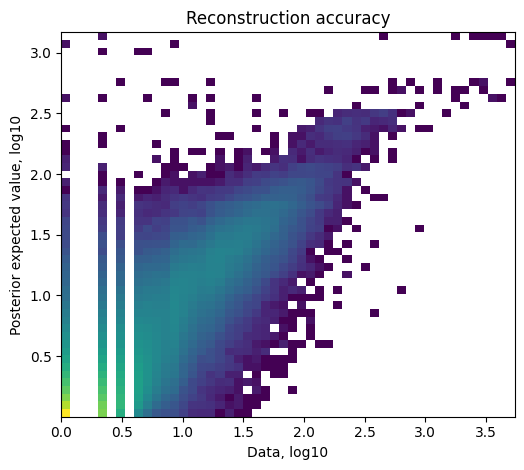

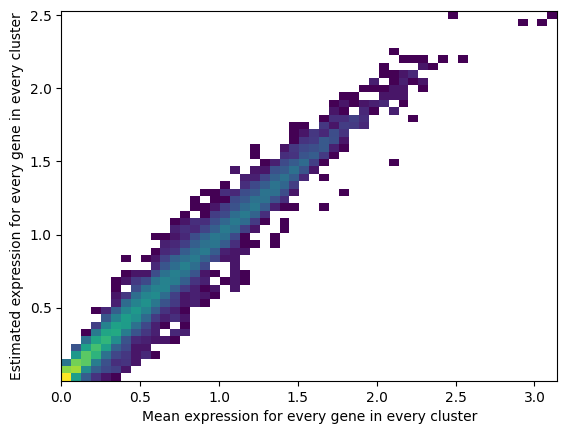

In [30]:
mod.plot_QC()

可以使用以下代码读入保存的结果

In [22]:
# ref_run_name = "../tmp/cel2location_ref"
# adata_file = f"{ref_run_name}/sc.h5ad"
# adata_ref = sc.read_h5ad(adata_file)
# mod = cell2location.models.RegressionModel.load(f"{ref_run_name}", adata_ref)

INFO     File ../tmp/cel2location_ref/model.pt already downloaded                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/273:   0%|                            | 1/273 [00:00<01:56,  2.34it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/273:   0%|                            | 1/273 [00:00<01:57,  2.31it/s, v_num=1]


## Mapping spatial

In [31]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,B_Cycling,B_GC_DZ,B_GC_LZ,B_GC_prePB,B_IFN
GeneID-2,,,,,
ENSG00000188976,0.389689,0.223033,0.283479,0.317551,0.137545
ENSG00000188290,0.001806,0.000734,0.000745,0.045783,0.046974
ENSG00000187608,0.392362,0.229007,0.289238,0.520519,3.844927
ENSG00000186891,0.020267,0.000978,0.052648,0.065103,0.009674
ENSG00000186827,0.007459,0.000579,0.006074,0.031890,0.010503


取reference和query的基因的交集

In [32]:
# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="sample")

In [33]:
# create and train the model
mod = cell2location.models.Cell2location(
    adata_vis, cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=30,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.0.4.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 4035  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 10217 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                       batch State Registry                        
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃     Categories      ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ V1_Human_Lymph_Node │          0          │
└─────────────────────┴─────────────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

In [37]:
import torch

if torch.cuda.is_available():
    mod.train(max_epochs=10000,
              # train using full data (batch_size=None)
              batch_size=None,
              # use all data points in training because
              # we need to estimate cell abundance at all locations
              train_size=1,
              use_gpu=True,
             )
else:
    mod.train(max_epochs=10000, batch_size=None, train_size=1, use_gpu=False)

/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/scvi/train/_trainrunner.py:76: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:281: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 1747/10000:  17%|▏| 1746/10000 [02:10<09:56, 13.84it/s, v_num=1, elbo_train=4.58e

/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/call.py:53: Detected KeyboardInterrupt, attempting graceful shutdown...


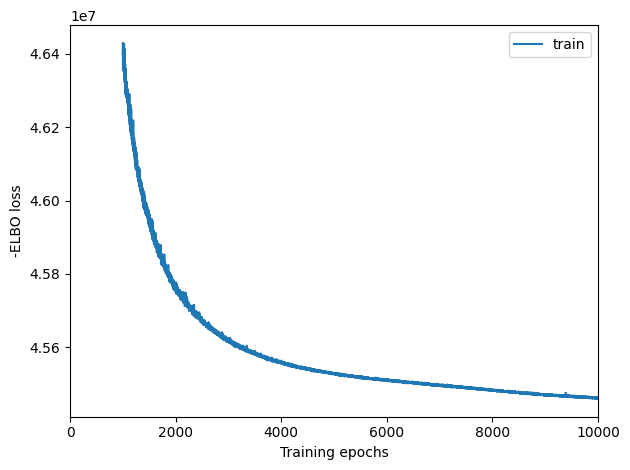

In [39]:
mod.plot_history(1000)

In [46]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
import torch

if torch.cuda.is_availableailable():
    adata_vis = mod.export_posterior(
        adata_vis, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs, 'use_gpu': True}
    )
else:
    adata_vis = mod.export_posterior(
        adata_vis, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs, 'use_gpu': False}
    )

/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


Sampling global variables, sample: 100%|█████████████| 999/999 [00:16<00:00, 61.21it/s]


In [ ]:
run_name = "../tmp/cel2location_vis"

# Save model
mod.save(f"{run_name}", overwrite=True)

# mod = cell2location.models.Cell2location.load(f"{run_name}", adata_vis)

# Save anndata object with results
adata_file = f"{run_name}/sp.h5ad"
adata_vis.write(adata_file)
adata_file

使用以下代码导入结果

In [38]:
# run_name = "../tmp/cel2location_vis"
# mod = cell2location.models.Cell2location.load(f"{run_name}", adata_vis)

INFO     File ../tmp/cel2location_vis/model.pt already downloaded                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:281: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 1/30000:   0%|                      | 1/30000 [00:00<1:09:44,  7.17it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/30000:   0%|                      | 1/30000 [00:00<1:13:48,  6.77it/s, v_num=1]


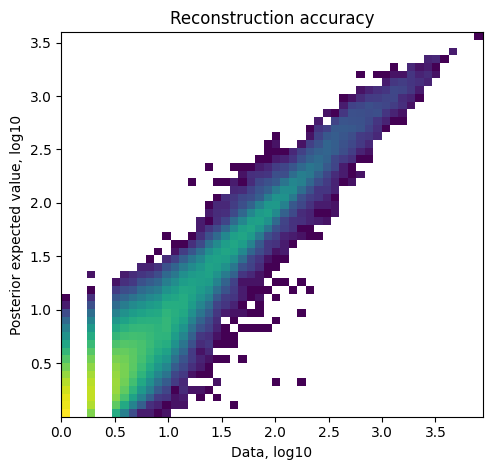

In [47]:
mod.plot_QC()

In [48]:
adata_vis.uns['spatial'].keys()

dict_keys(['V1_Human_Lymph_Node'])

In [52]:
# add 5% quantile, representing confident cell abundance, 'at least this amount is present',
# to adata.obs with nice names for plotting
adata_vis.obs[adata_vis.uns['mod']['factor_names']] = adata_vis.obsm['q05_cell_abundance_w_sf']

In [56]:
adata_vis.uns['spatial'].keys()

dict_keys(['V1_Human_Lymph_Node'])

/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


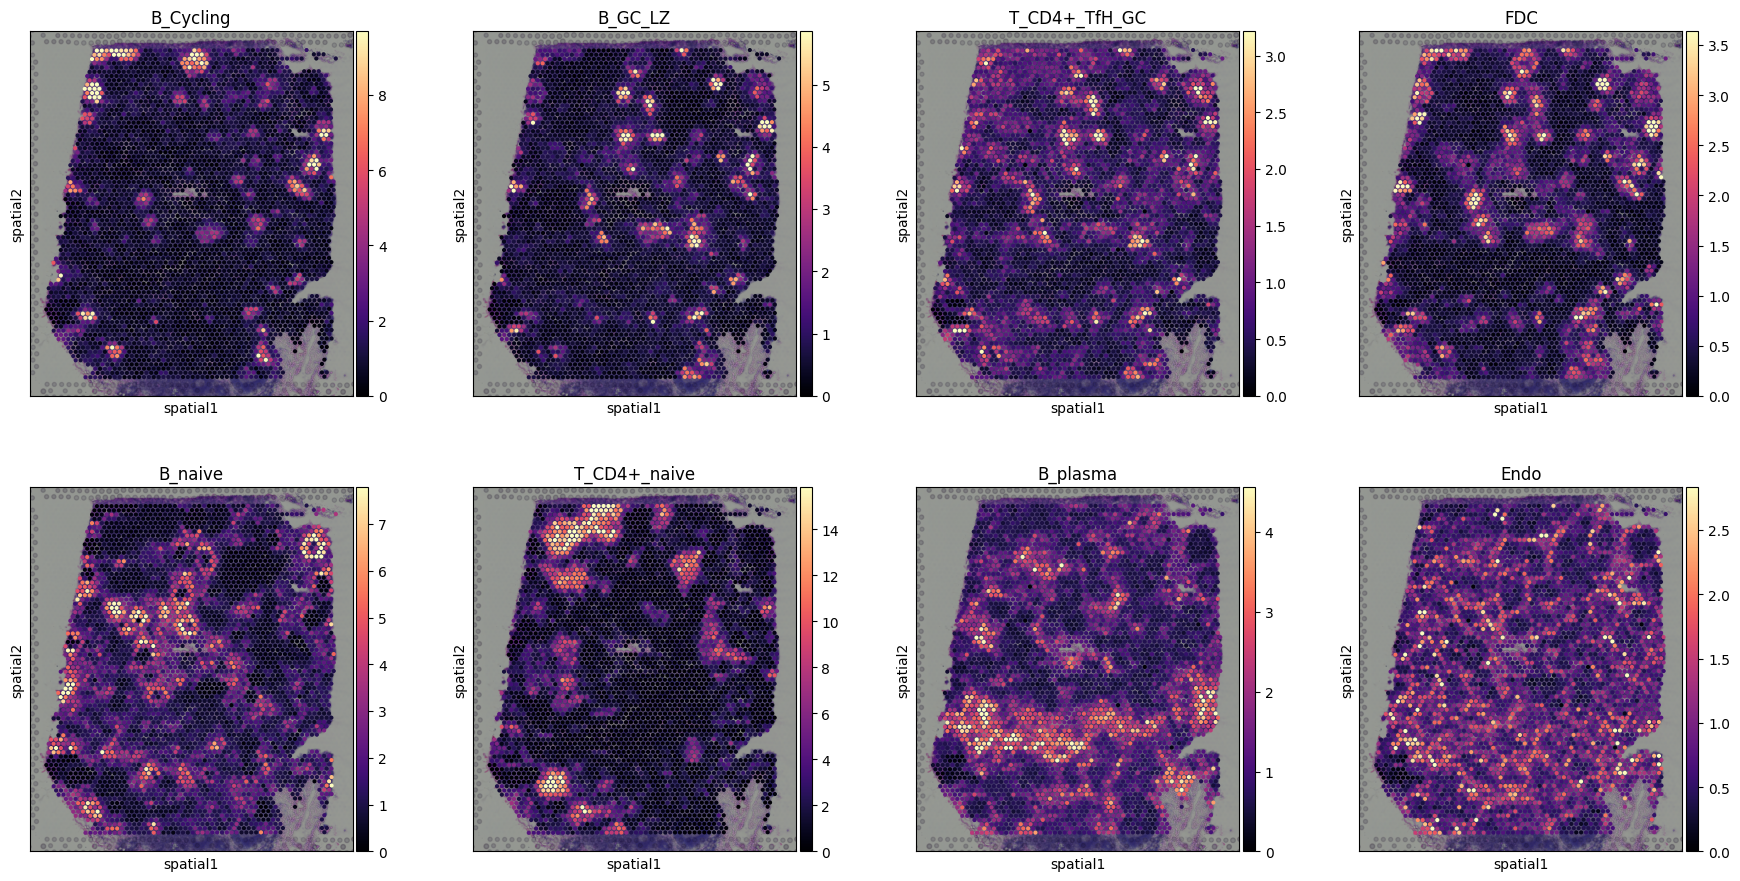

In [57]:
# select one slide
from cell2location.utils import select_slide
slide = select_slide(adata_vis, 'V1_Human_Lymph_Node')

# plot in spatial coordinates
with mpl.rc_context({'axes.facecolor':  'black',
                     'figure.figsize': [4.5, 5]}):

    sc.pl.spatial(slide, cmap='magma',
                  # show first 8 cell types
                  color=['B_Cycling', 'B_GC_LZ', 'T_CD4+_TfH_GC', 'FDC',
                         'B_naive', 'T_CD4+_naive', 'B_plasma', 'Endo'],
                  ncols=4, size=1.3,
                  img_key='hires',
                  # limit color scale at 99.2% quantile of cell abundance
                  vmin=0, vmax='p99.2'
                 )

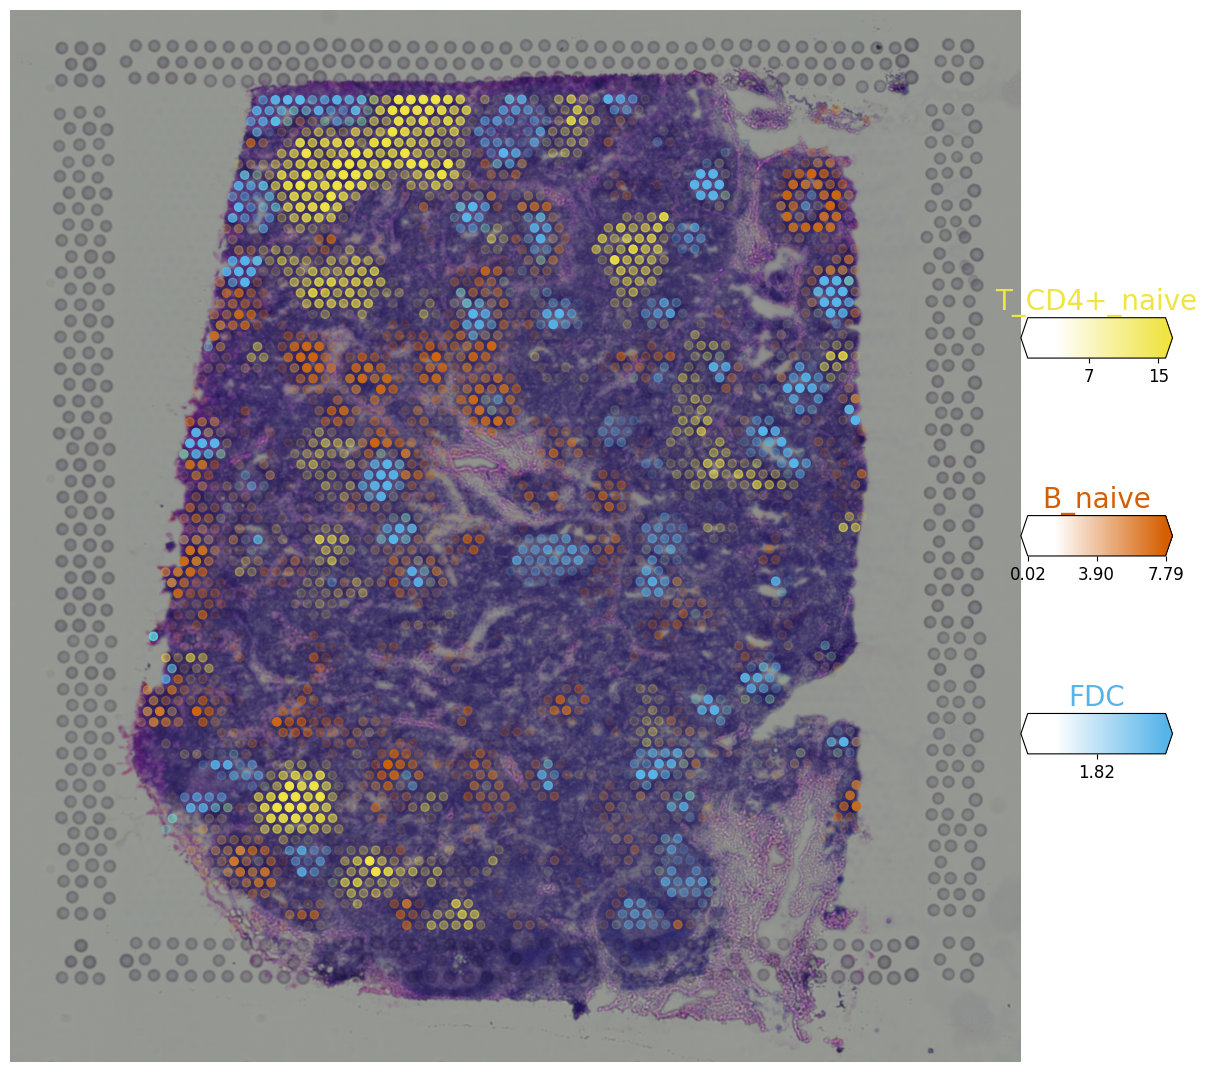

In [58]:
# Now we use cell2location plotter that allows showing multiple cell types in one panel
from cell2location.plt import plot_spatial

# select up to 6 clusters
clust_labels = ['T_CD4+_naive', 'B_naive', 'FDC']
clust_col = ['' + str(i) for i in clust_labels] # in case column names differ from labels

slide = select_slide(adata_vis, 'V1_Human_Lymph_Node')

with mpl.rc_context({'figure.figsize': (15, 15)}):
    fig = plot_spatial(
        adata=slide,
        # labels to show on a plot
        color=clust_col, labels=clust_labels,
        show_img=True,
        # 'fast' (white background) or 'dark_background'
        style='fast',
        # limit color scale at 99.2% quantile of cell abundance
        max_color_quantile=0.992,
        # size of locations (adjust depending on figure size)
        circle_diameter=6,
        colorbar_position='right'
    )

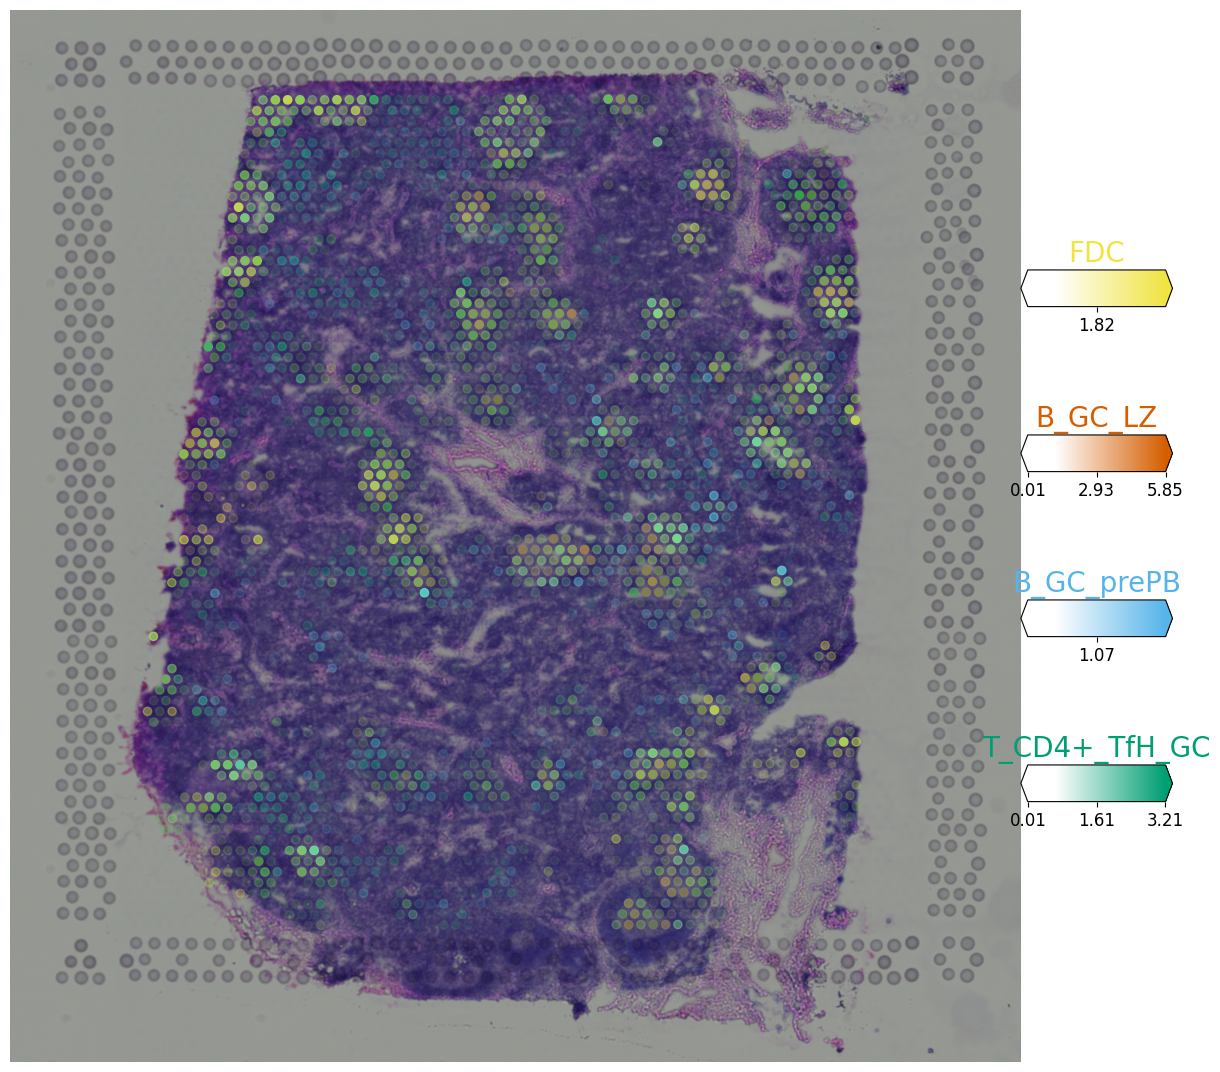

In [62]:
# Now we use cell2location plotter that allows showing multiple cell types in one panel
from cell2location.plt import plot_spatial

# select up to 6 clusters
clust_labels = ["FDC", "B_GC_LZ", "B_GC_prePB", "T_CD4+_TfH_GC"]

clust_col = ['' + str(i) for i in clust_labels] # in case column names differ from labels

slide = select_slide(adata_vis, 'V1_Human_Lymph_Node')

with mpl.rc_context({'figure.figsize': (15, 15)}):
    fig = plot_spatial(
        adata=slide,
        # labels to show on a plot
        color=clust_col, labels=clust_labels,
        show_img=True,
        # 'fast' (white background) or 'dark_background'
        style='fast',
        # limit color scale at 99.2% quantile of cell abundance
        max_color_quantile=0.992,
        # size of locations (adjust depending on figure size)
        circle_diameter=6,
        colorbar_position='right'
    )
plt.savefig('figure_cell2location.pdf')

In [64]:
from cell2location import run_colocation
res_dict, adata_vis = run_colocation(
    adata_vis,
    model_name='CoLocatedGroupsSklearnNMF',
    train_args={
      'n_fact': np.arange(5, 13), # IMPORTANT: use a wider range of the number of factors (5-30)
      'sample_name_col': 'sample', # columns in adata_vis.obs that identifies sample
      'n_restarts': 3 # number of training restarts
    },
    # the hyperparameters of NMF can be also adjusted:
    model_kwargs={'alpha': 0.01, 'init': 'random', "nmf_kwd_args": {"tol": 0.000001}},
    export_args={'path': f'{run_name}/test/'}
)

### Analysis name: CoLocatedGroupsSklearnNMF_5combinations_4035locations_34factors


/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


### Analysis name: CoLocatedGroupsSklearnNMF_6combinations_4035locations_34factors


/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


### Analysis name: CoLocatedGroupsSklearnNMF_7combinations_4035locations_34factors


...

/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


### Analysis name: CoLocatedGroupsSklearnNMF_11combinations_4035locations_34factors


/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


### Analysis name: CoLocatedGroupsSklearnNMF_12combinations_4035locations_34factors


/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jarning/miniconda3/envs/scvi-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):
